In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [2]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [3]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x)

In [5]:
labels = torch.zeros((16, 1000)).to("cuda")
for i in range(16):
    labels[i, i] = 1

In [6]:
sigma_min = 0.002
sigma_max = 80

# sde_ = sde.EDMSDE().to("cuda")
sde_ = sde.VarianceExplodingEDMSDE(sigma_min, sigma_max).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")
rsde.ode = False

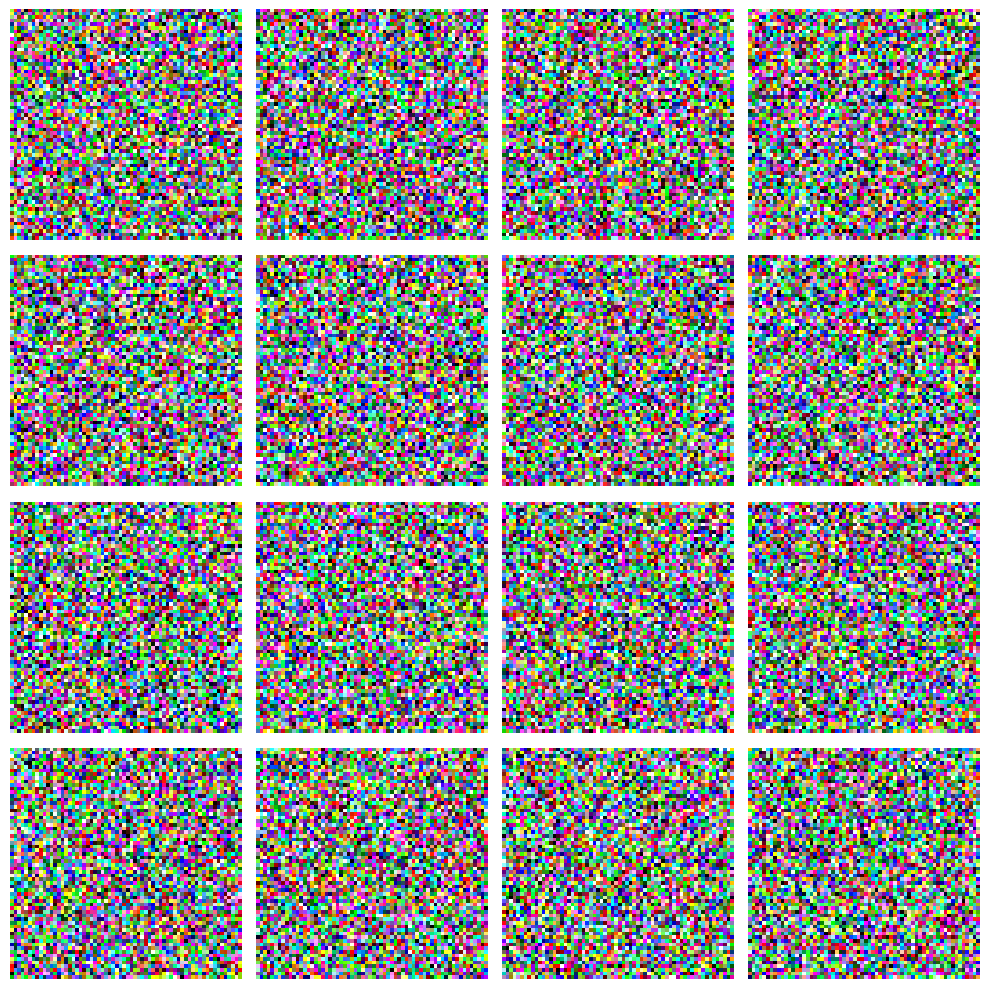

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [8]:
n_steps = 200
rho = 7
# From EDM2 code
# step_indices = torch.arange(n_steps)
# sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
# discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])
discretisation = torch.linspace(1, 0, n_steps)

em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

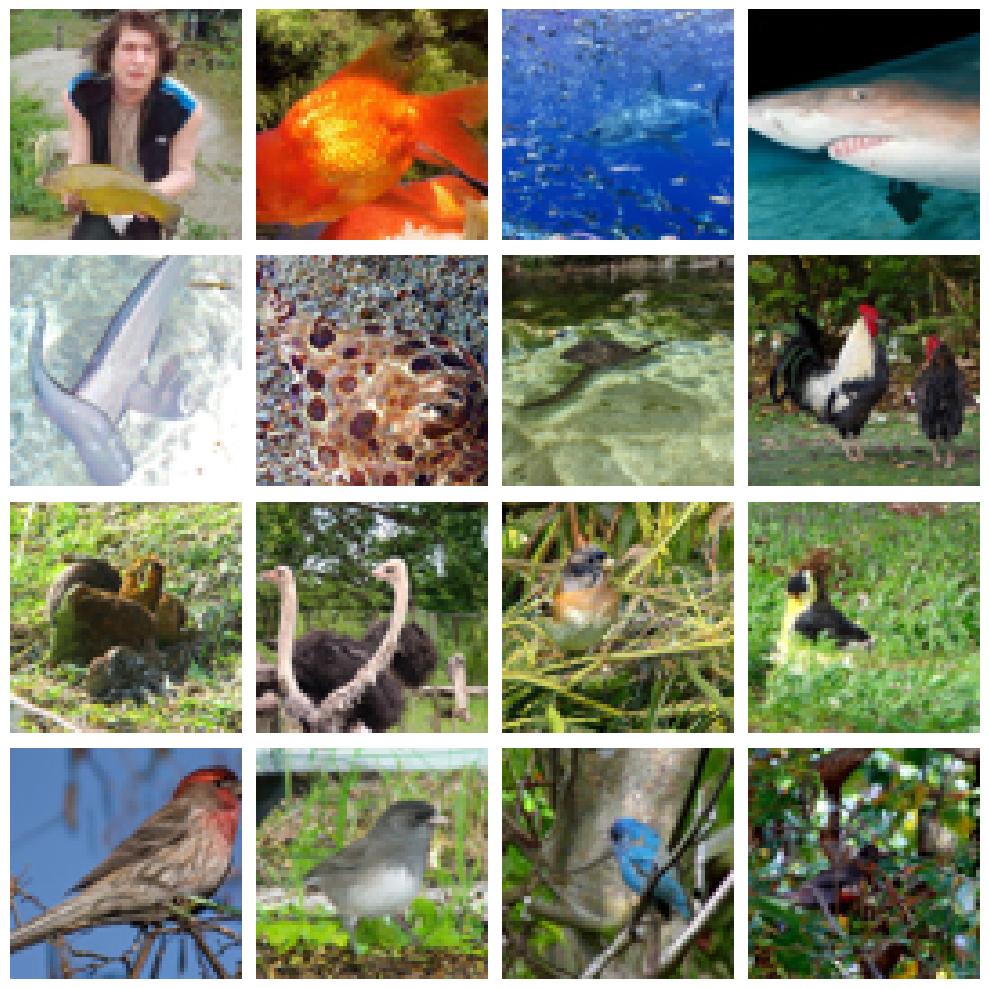

In [9]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [20]:
rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.101, 
    kp=0.09, 
    tau=1.3, 
    alpha=0.7,
    h_start=0.001,
    max_h=0.1,
    max_decrease=0.7,
    max_increase=1.3,
    timeout=1000,
    interval=(1, 0),
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels)

T = 1.0, h = -0.0008761669741943479
T = 1.0, h = -0.0008720171172171831
T = 1.0, h = -0.0008542326977476478
T = 1.0, h = -0.0008415988413617015
T = 1.0, h = -0.0008298641769215465
T = 1.0, h = -0.0008207428618334234
T = 1.0, h = -0.0008121285354718566
T = 0.9998477697372437, h = -0.0008053425699472427
T = 0.9992438554763794, h = -0.0007986658019945025
T = 0.9984451532363892, h = -0.0007944759563542902
T = 0.9976507425308228, h = -0.0007916153408586979
T = 0.9968591928482056, h = -0.00078962417319417
T = 0.9960694909095764, h = -0.0007880634511820972
T = 0.995281457901001, h = -0.0007882536738179624
T = 0.9944931268692017, h = -0.0007874105358496308
T = 0.9937057495117188, h = -0.0007880501798354089
T = 0.9929177165031433, h = -0.0007894442533142865
T = 0.9921282529830933, h = -0.0007909407140687108
T = 0.9913372993469238, h = -0.0007932554581202567
T = 0.9905440807342529, h = -0.0007950644940137863
T = 0.9897489547729492, h = -0.0007979563670232892
T = 0.9889510273933411, h = -0.000801

In [21]:
rsde.nfe / 16

444.75

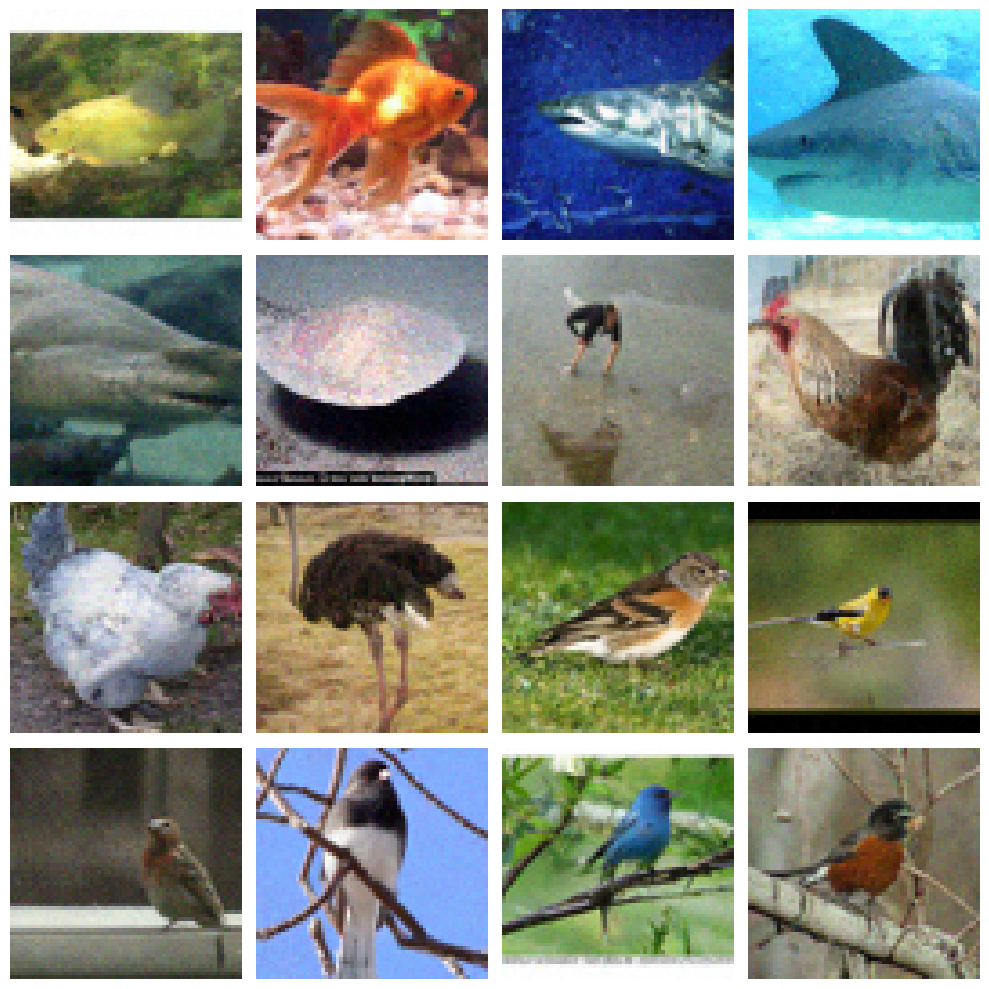

In [22]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())